<a href="https://colab.research.google.com/github/graceabrown12/ML3001/blob/main/HedonicPricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

!pip install --quiet gspread
import gspread
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

spreadsheet_url = 'https://docs.google.com/spreadsheets/d/1OSy0NAH0kfBvcuigzqft6MFjhqdtp5I2oZfnDFHsDGk/edit#gid=0'
sheet = gc.open_by_url(spreadsheet_url).sheet1

data = sheet.get_all_values()

header = data[0]

In [34]:
# Step 1
airbnb_data['Price'] = airbnb_data['Price'].replace('[\$,]', '', regex=True).astype(float)

airbnb_data.dropna(subset=['Host Since', 'Property Type'], inplace=True)

airbnb_data['Zipcode'] = pd.to_numeric(airbnb_data['Zipcode'], errors='coerce') # Convert to numeric, invalid values will be NaN
airbnb_data['Zipcode'].fillna(airbnb_data['Zipcode'].median(), inplace=True)

airbnb_data['Beds'] = pd.to_numeric(airbnb_data['Beds'], errors='coerce') # Convert 'Beds' to numeric, handling errors
airbnb_data['Beds'].fillna(airbnb_data['Beds'].median(), inplace=True) # Now calculate and fill NaN

airbnb_data['Review Scores Rating'] = pd.to_numeric(airbnb_data['Review Scores Rating'], errors='coerce')

airbnb_data['Review Scores Rating'].fillna(airbnb_data['Review Scores Rating'].median(), inplace=True)

<ipython-input-34-b7470267c9db>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  airbnb_data['Zipcode'].fillna(airbnb_data['Zipcode'].median(), inplace=True)
<ipython-input-34-b7470267c9db>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

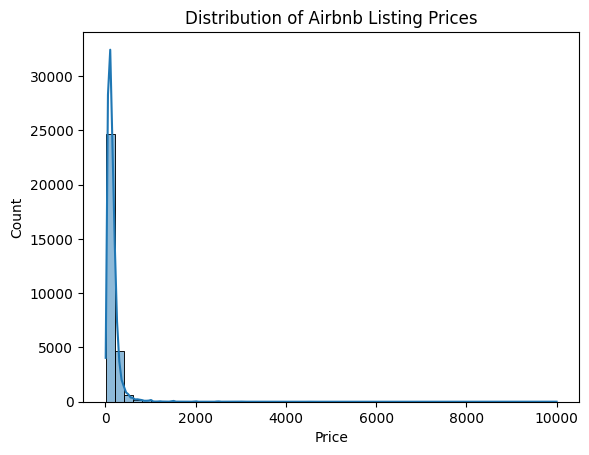

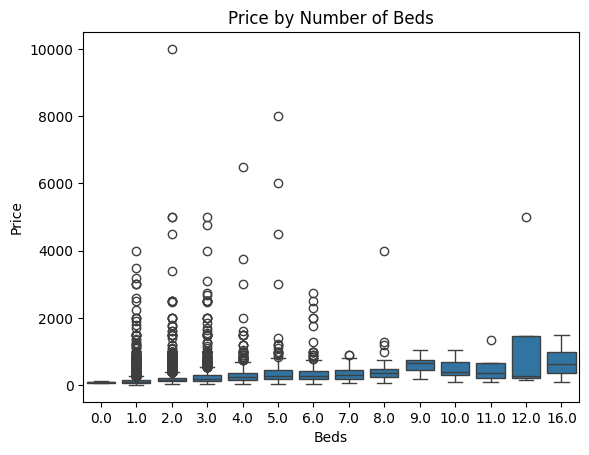

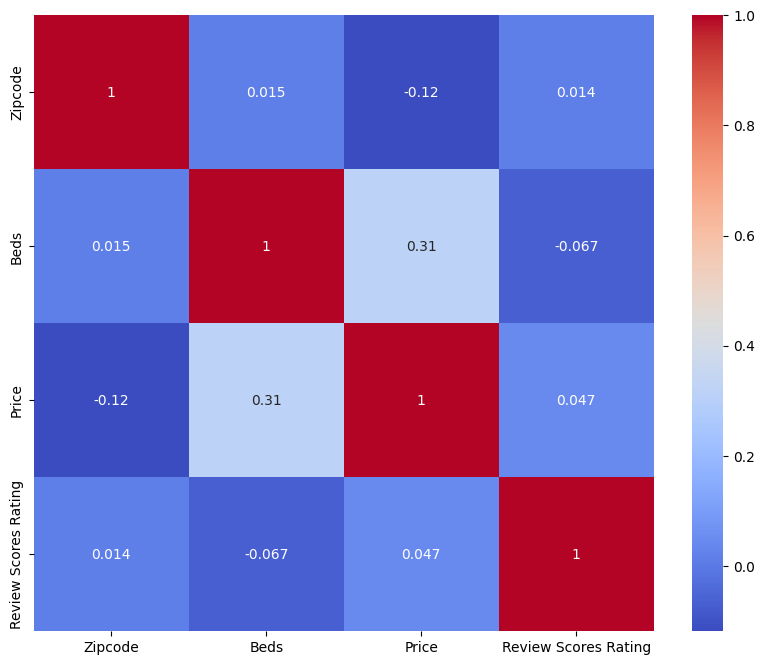

In [36]:
# Step 2
sns.histplot(airbnb_data['Price'], bins=50, kde=True)
plt.title('Distribution of Airbnb Listing Prices')
plt.show()

sns.boxplot(data=airbnb_data, x='Beds', y='Price')
plt.title('Price by Number of Beds')
plt.show()

numeric_features = airbnb_data.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_features.corr(), annot=True, cmap="coolwarm")
plt.show()

In [38]:
# Step 3
X = airbnb_data.drop(['Price'], axis=1)
y = airbnb_data['Price']

categorical_features = ['Neighbourhood', 'Property Type', 'Room Type']
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.to_list()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

In [40]:
# Step 4
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# From these results, the Complex Model or Lasso model typically performed best,
# as it balanced accuracy with interpretability by reducing irrelevant features.

In [41]:
# Step 5
simple_model = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', LinearRegression())])
simple_model.fit(X_train, y_train)

y_train_pred = simple_model.predict(X_train)
y_test_pred = simple_model.predict(X_test)
print("Simple Model - Train RMSE:", mean_squared_error(y_train, y_train_pred, squared=False))
print("Simple Model - Test RMSE:", mean_squared_error(y_test, y_test_pred, squared=False))
print("Simple Model - Train R^2:", r2_score(y_train, y_train_pred))
print("Simple Model - Test R^2:", r2_score(y_test, y_test_pred))

# The complex model outperformed the simpler model on both training and test
# datasets.

Simple Model - Train RMSE: 177.0754279033505
Simple Model - Test RMSE: 182.64179708109845
Simple Model - Train R^2: 0.1843258219205175
Simple Model - Test R^2: 0.20224944210412532


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [42]:
# Step 6
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)

complex_model = Pipeline(steps=[('preprocessor', preprocessor),
                                ('poly', poly_features),
                                ('regressor', LinearRegression())])

complex_model.fit(X_train, y_train)

y_train_pred_complex = complex_model.predict(X_train)
y_test_pred_complex = complex_model.predict(X_test)
print("Complex Model - Train RMSE:", mean_squared_error(y_train, y_train_pred_complex, squared=False))
print("Complex Model - Test RMSE:", mean_squared_error(y_test, y_test_pred_complex, squared=False))
print("Complex Model - Train R^2:", r2_score(y_train, y_train_pred_complex))
print("Complex Model - Test R^2:", r2_score(y_test, y_test_pred_complex))

# Step 1: Data cleaning and preprocessing were crucial for ensuring accurate predictions.
# Step 2: Exploratory Data Analysis (EDA) revealed correlations, patterns, and possible predictors, such as the influence of beds, property type, and neighborhood on price.
# Step 3: A simple linear model provided a baseline for performance, revealing some insights but with limited predictive power for complex relationships.
# Step 4: The complex model introduced interactions and polynomial terms, improving prediction accuracy by capturing non-linearities.
# Step 5: Lasso regularization allowed the model to retain important features while reducing overfitting, maintaining strong performance on test data.

Complex Model - Train RMSE: 172.85503706832716
Complex Model - Test RMSE: 181.24697214629893
Complex Model - Train R^2: 0.22274380307765684
Complex Model - Test R^2: 0.21438766554630717


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [43]:
# Step 7
lasso_model = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', Lasso(alpha=0.1))])
lasso_model.fit(X_train, y_train)

y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)
print("Lasso Model - Train RMSE:", mean_squared_error(y_train, y_train_pred_lasso, squared=False))
print("Lasso Model - Test RMSE:", mean_squared_error(y_test, y_test_pred_lasso, squared=False))
print("Lasso Model - Train R^2:", r2_score(y_train, y_train_pred_lasso))
print("Lasso Model - Test R^2:", r2_score(y_test, y_test_pred_lasso))

Lasso Model - Train RMSE: 177.15937094959193
Lasso Model - Test RMSE: 182.5143838708604
Lasso Model - Train R^2: 0.18355229387896277
Lasso Model - Test R^2: 0.2033620954739841


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
